# Crick CellPose_Sam
## This is a notebook made in the CALM facility at the Francis Crick Institute to get people going on using CellPose-Sam for predicting on images

## This notebook is made for 2D images! Please check the documentation or talk to Todd, Dave or Sara from CALM if you want to extend to 3D.

## This notebook works on nemo using cellpose_env_0525.

### The notebook was cribbed from: https://github.com/MouseLand/cellpose/blob/main/notebooks/run_Cellpose-SAM.ipynb

### Environment installation documentation can be found here:

#### Last updated May 20, 2025


## Import the necessary packages for running CellPose

In [1]:
import numpy as np
from cellpose import models, core, io, plot
from cellpose.io import imread
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
from glob import glob
from datetime import datetime
import time
import os



Welcome to CellposeSAM, cellpose v4.0.1! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




## Check to make sure you are running in a GPU node.  If this next cell shows "No GPU access, change your runtime" make sure that you requested a GPU

### If a GPU is seen by the environment, you should see:
**TORCH CUDA version installed and working**

In [2]:
io.logger_setup() # run this to get printing of progress

#Check if notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

2025-05-20 16:21:05,013 [INFO] WRITING LOG OUTPUT TO /camp/home/fallest/.cellpose/run.log
2025-05-20 16:21:05,013 [INFO] 
cellpose version: 	4.0.1 
platform:       	linux 
python version: 	3.11.12 
torch version:  	2.7.0+cu126
2025-05-20 16:21:05,300 [INFO] ** TORCH CUDA version installed and working. **


## These next code blocks are for running on a single image

If the image has multiple channels, cellpose will predict for each channel.  New versions of cellpose don't require we specify the model we want to use.

You will want to change the path to where you put the images

In [4]:
##specify the image path
image_path = '/nemo/lab-name/working/username/path_to_cellpose_images/Cells_01.tif'
img = imread(image_path) # read in the image
img.shape

(3, 1024, 1280)

In [5]:
def image_with_channels_last(img):
    #function which returns an image with the channels always last
    
    img_dims = img.ndim
    img_shape = img.shape
    
    if img_dims == 2:
        return img  #this is when the image only has x and y anyways
    elif img_dims ==3:
        if img_shape[0] < 4 and img_shape[1] > 4 and img_shape[2] > 4:
            img = np.transpose(img, (1, 2, 0))
            return img
        else:
            return img #image was already properly formatted
    if img_dims > 3:
        print("this image has got too many dimensions, we leave it as an excercise to the reader to figure out")
        return 0
    

def plot_channel_montage(img, cmap='gray'):
    #Plots each channel of a (H, W, C) image in a montage

    if img.ndim == 2:
        plt.imshow(img)  ##if regular grayscale, displays the image again
    
    H, W, C = img.shape
    fig, axs = plt.subplots(1, C, figsize=(4*C, 4))

    if C == 1:
        axs = [axs]  # Make iterable

    for i in range(C):
        axs[i].imshow(img[:, :, i], cmap=cmap)
        axs[i].set_title(f'Channel {i+1}')
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()

def get_number_channels(img):
    if img.ndim==2:
        return 1
    else:
        return img.shape[2]

In [6]:
img = image_with_channels_last(img)
img.shape

(1024, 1280, 3)

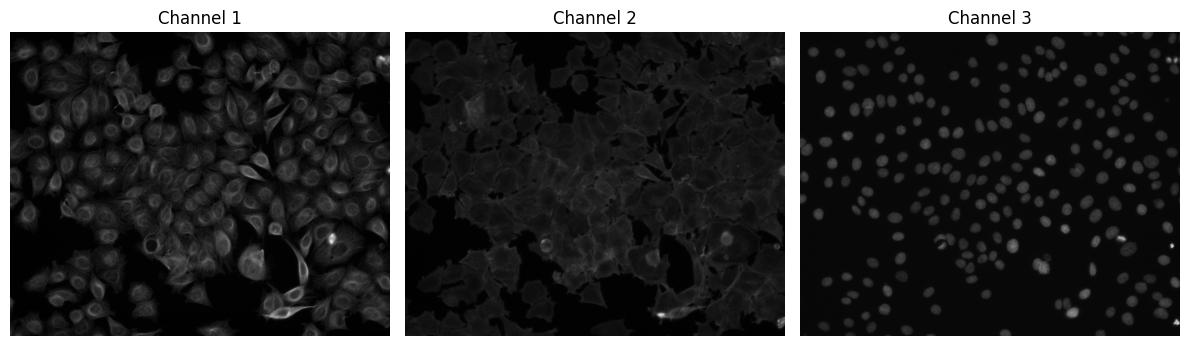

In [7]:
## plot the images
plot_channel_montage(img)

## Initialize the model and set some parameters

In [8]:
model = models.CellposeModel(gpu=True)  ##Initialize the model

2025-05-20 16:22:14,405 [INFO] ** TORCH CUDA version installed and working. **
2025-05-20 16:22:14,406 [INFO] >>>> using GPU (CUDA)
2025-05-20 16:22:16,141 [INFO] >>>> loading model /camp/home/fallest/.cellpose/models/cpsam


In [9]:
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

num_channels = get_number_channels(img)



In [10]:
#pre-allocate an array for the masks, create a zeros array the same size as the img
masks = np.zeros_like(img)
flows_array = []

In [11]:
for k in range(0, num_channels):
    print("Working on channel: ", k)
    if num_channels>1:
        masks[:,:,k], flows, styles = model.eval(img[:,:,k], batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    else:
        masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
        
    flows_array.append(flows)
    
    

Working on channel:  0
Working on channel:  1
Working on channel:  2


## Show the masks

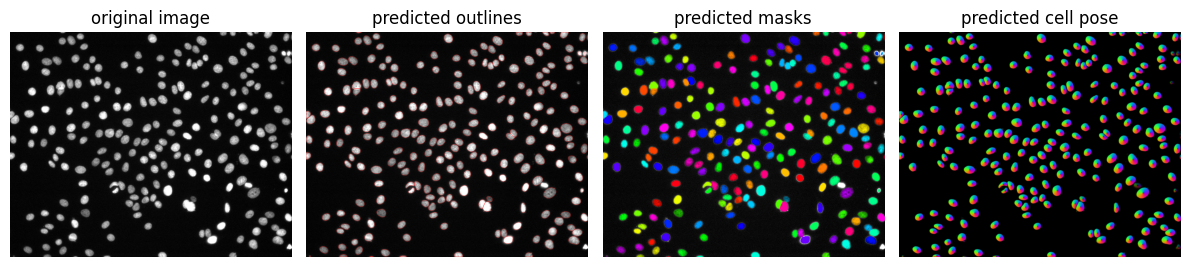

In [12]:
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img[:,:,2], masks[:,:,2], flows_array[2][0], channels=[0,0], file_name=None)
plt.tight_layout()
plt.show()

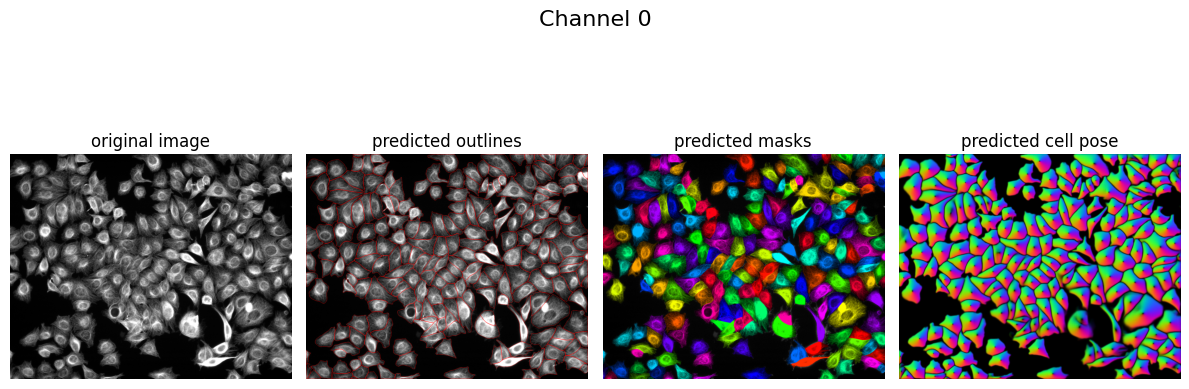

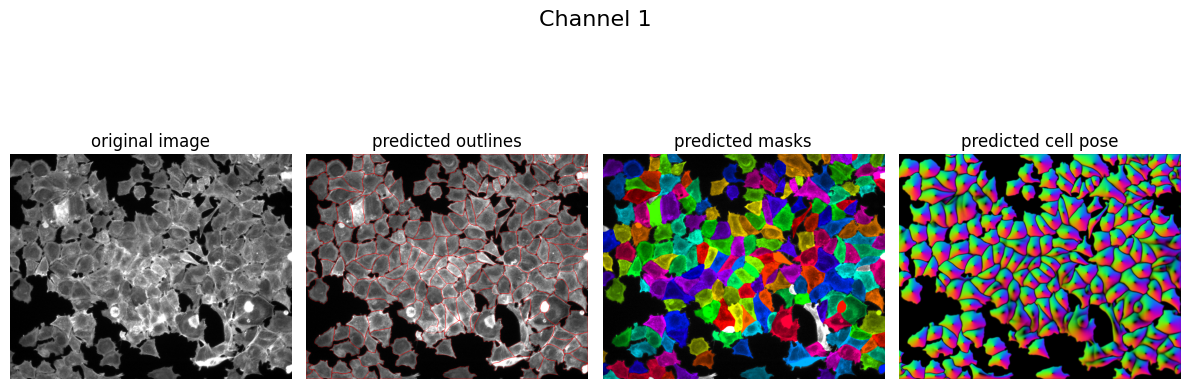

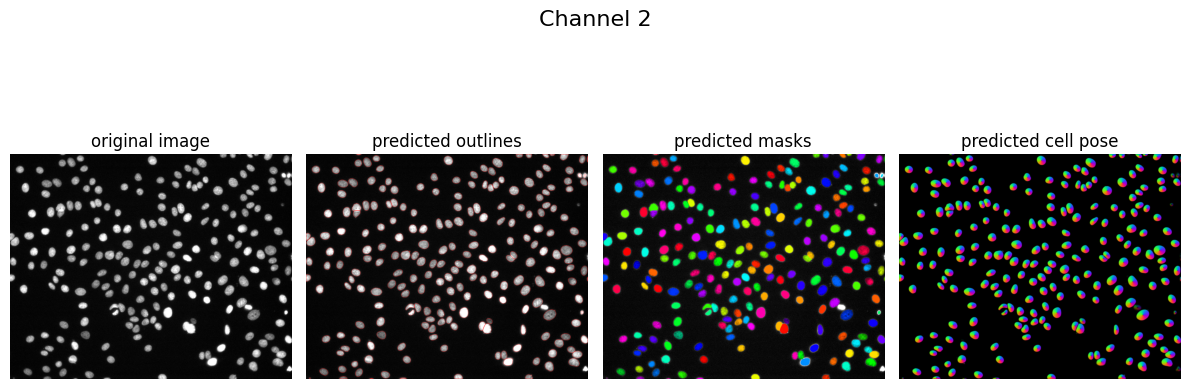

In [13]:
for i in range(3):
    fig = plt.figure(figsize=(12, 5))
    plot.show_segmentation(
        fig,
        img[:, :, i],
        masks[:, :, i],
        flows_array[i][0],         
        channels=[0, 0],
        file_name=None
    )
    plt.suptitle(f"Channel {i}", fontsize=16)
    plt.tight_layout()
    plt.show()

## Save the masks out

In [14]:
filename_raw = os.path.splitext(os.path.basename(image_path))[0]
ext = os.path.splitext(os.path.basename(image_path))[1]

dir_path = os.path.dirname(image_path)
timestamp = datetime.now().strftime("%Y_%m_%d_%H%M%S")
output_dir=os.path.join(dir_path, 'output', timestamp)
os.makedirs(output_dir, exist_ok=True)
filename_out = filename_raw + "_masks"+ext
output_path = os.path.join(output_dir, filename_out)

io.imsave(output_path, masks)
print(output_path)

/nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/output/2025_05_20_162231/Cells_01_masks.tif


## Run Cellpose over all the images in a folder and save the output

In [ ]:
##Specify the path that the images are in


In [15]:
dir_path = '/nemo/lab-name/working/username/path_to_cellpose_images/'
extension = '*.tif'
file_list = glob(os.path.join(dir_path, extension))


    

In [16]:
file_list[0]  #sanity check, make sure you've got some files

'/nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/Cells_01.tif'

In [17]:
#set the parameters 
model = models.CellposeModel(gpu=True)  ##Initialize the model
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0


2025-05-20 16:26:11,913 [INFO] ** TORCH CUDA version installed and working. **
2025-05-20 16:26:11,913 [INFO] >>>> using GPU (CUDA)
2025-05-20 16:26:13,666 [INFO] >>>> loading model /camp/home/fallest/.cellpose/models/cpsam


In [18]:
timestamp = datetime.now().strftime("%Y_%m_%d_%H%M%S") ##this creates a new time_stamped output folder per run. 
                                                        # This may or may not be useful to you, depending on how many runs you do
for image_path in file_list:
    #set up the image block
    print("Working on: ", image_path)
    img = imread(image_path) # read in the image
    img = image_with_channels_last(img)
    num_channels = get_number_channels(img)
    masks = np.zeros_like(img)
    flows_array = []
    
    #iterate over the channels block
    for k in range(0, num_channels):
        print("Working on channel: ", k)
        if num_channels>1:
            masks[:,:,k], flows, styles = model.eval(img[:,:,k], batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                      normalize={"tile_norm_blocksize": tile_norm_blocksize})
        else:
            masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                      normalize={"tile_norm_blocksize": tile_norm_blocksize})

        flows_array.append(flows)
        
    #save image block    
    filename_raw = os.path.splitext(os.path.basename(image_path))[0]
    ext = os.path.splitext(os.path.basename(image_path))[1]

    input_path = os.path.dirname(image_path)
    output_path = os.path.join(input_path, 'output', timestamp)
    os.makedirs(output_path, exist_ok=True)
    filename_out = filename_raw + "_masks"+ext
    file_out_path = os.path.join(output_path, filename_out)
    io.imsave(file_out_path, masks)
    print(file_out_path)

Working on:  /nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/Cells_01.tif
Working on channel:  0
Working on channel:  1
Working on channel:  2
/nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/output/2025_05_20_162617/Cells_01_masks.tif
Working on:  /nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/C-004_S-000_S_APC_R-01_W-A01_ROI-01_A-CD8a_AF647_C-EPR21769.tif
Working on channel:  0
/nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/output/2025_05_20_162617/C-004_S-000_S_APC_R-01_W-A01_ROI-01_A-CD8a_AF647_C-EPR21769_masks.tif
Working on:  /nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/gfp.tif
Working on channel:  0
/nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/output/2025_05_20_162617/gfp_masks.tif
Working on:  /nemo/stp/lm/working/fallest/Projects/Cecile_Piot/images_input/dapi.tif
Working on channel:  0
2025-05-20 16:38:34,970 [WARNING] more than 65535 masks in image, masks returned as np.uint32
/ne

https://github.com/MouseLand/cellpose/blob/main/cellpose/plot.py